# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [ ]:
import pandas as pd

In [2]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [4]:
df.info()
categorical_columns = df.select_dtypes(include=['object']).columns

print("\n\nDistinct values in categorical columns:")
for col in categorical_columns:
    print(f"{col}({len(df[col].unique())}): {df[col].unique()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
# core libraries and viz.
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Text(0.5, 1.05, 'Distribution Plot of Numerical Features')

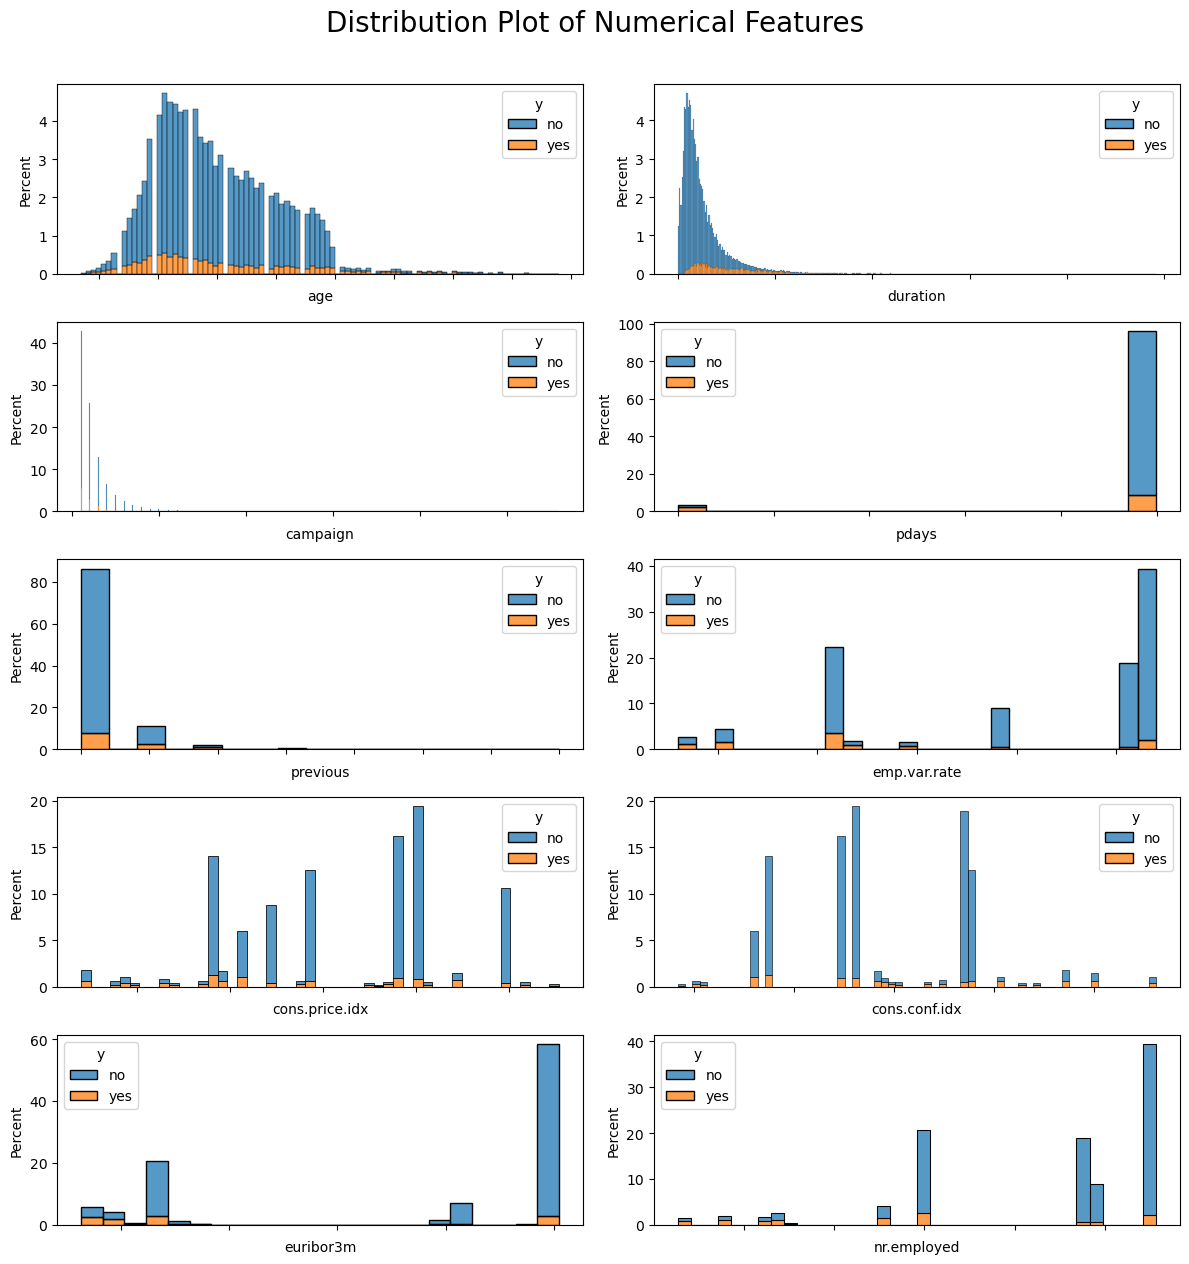

In [6]:
# Box plots of the Numerical features to examine the distribution of the features
numerical_columns = []
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Distribution Plot of the Numerical features 
fig, axs = plt.subplots(nrows = 5, ncols=2, figsize = (12,12))
for name,ax in zip(numerical_columns,axs.flatten()):
    sns.histplot(data=df,x=name,ax=ax,hue='y',multiple='stack',stat='percent')
    ax.set_xticklabels(ax.get_xticklabels(minor=True,which='minor'),rotation=0,fontsize=50)

fig.tight_layout()
fig.suptitle('Distribution Plot of Numerical Features',y=1.05,fontsize=20)

<Axes: >

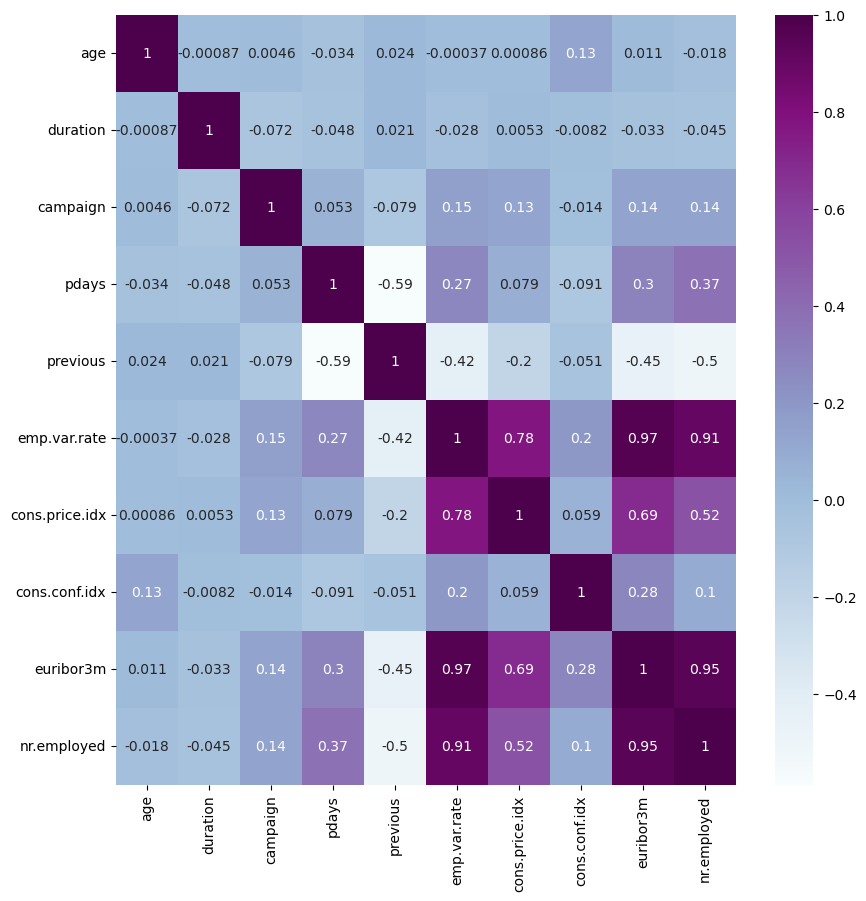

In [7]:
# Correlation Matrix of the numerical features
plt.figure(figsize=(10, 10))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='BuPu')

Some of the features of the data - 
- All the rows have data in them. No null data in any columns.
- The total distinct values in all the categorical columns have a distinct value count between 2 to 12. One hot encoding is feasible.
- Discard "duration" column from the feature set as it can skew the output greatly.

### Business Objective

We leverage a dataset from a Portuguese banking institution containing results from 17 direct marketing campaigns with over 79,354 customer contacts. Our goal is to **develop a predictive model that accurately identifies customers likely to subscribe to a term deposit** (long-term deposit with favorable interest rates) based on their demographic, financial, and campaign interaction characteristics.

**Classification Approach:**
We will compare the predictive performance of four distinct classification algorithms:
- **K-Nearest Neighbors (KNN)** - Instance-based learning method
- **Logistic Regression (LR)** - Linear probabilistic classifier
- **Decision Trees (DT)** - Tree-based hierarchical classifier
- **Support Vector Machines (SVM)** - Kernel-based maximum margin classifier

By evaluating these methods on training time, training accuracy, and test accuracy, we will identify the most effective approach for this marketing campaign prediction task.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [8]:
# Convert target variable to binary (0 = 'no', 1 = 'yes')
df['y_numeric'] = (df['y'] == 'yes').astype(int)

# View the encoding
print(df[['y', 'y_numeric']].head())
print(f"Class distribution:\n{df['y_numeric'].value_counts()}")
print(f"Class distribution:\n{df['y'].value_counts()}") # To verify original labels

    y  y_numeric
0  no          0
1  no          0
2  no          0
3  no          0
4  no          0
Class distribution:
y_numeric
0    36548
1     4640
Name: count, dtype: int64
Class distribution:
y
no     36548
yes     4640
Name: count, dtype: int64


In [9]:
## Data Cleaning and Preparation

# Create a copy of the dataframe to preserve original
df_clean = df.copy()
print("Initial shape:", df_clean.shape)

# Drop columns with 'unknown' values exceeding threshold
threshold = 0.1  # 10%
for col in categorical_columns:
    unknown_ratio = (df_clean[col] == 'unknown').mean()
    if unknown_ratio > threshold:
        df_clean.drop(columns=[col], inplace=True)
        print(f"Dropped column '{col}' due to high 'unknown' ratio: {unknown_ratio:.2%}")

# Turns out 'default' had high unknowns, so we dont need to explicitly drop it again

# Drop low-value features before encoding
columns_to_drop = ['day_of_week', 'month', 'contact', 
                   'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 
                   'euribor3m', 'nr.employed', 'duration', 'pdays']

df_clean = df_clean.drop(columns=[col for col in columns_to_drop if col in df_clean.columns])

# Then apply one-hot encoding to remaining categorical columns
print("Shape after cleaning:", df_clean.shape)



Initial shape: (41188, 22)
Dropped column 'default' due to high 'unknown' ratio: 20.87%
Shape after cleaning: (41188, 11)


In [10]:
# Prepare features and target for modeling with ColumnTransformer
# This approach avoids data leakage by fitting preprocessor only on training data

# Extract features and target from raw data
# IMPORTANT: Drop both 'y' (string) and 'y_numeric' (encoded) to avoid data leakage
X = df_clean.drop(columns=['y', 'y_numeric'], errors='ignore')
y = (df_clean['y'] == 'yes').astype(int)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nClass distribution:")
print(y.value_counts())

# Identify feature types
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['number']).columns.tolist()

print(f"\nCategorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical features ({len(numerical_cols)}): {numerical_cols}")

Features shape: (41188, 9)
Target shape: (41188,)

Class distribution:
y
0    36548
1     4640
Name: count, dtype: int64

Categorical features (6): ['job', 'marital', 'education', 'housing', 'loan', 'poutcome']
Numerical features (3): ['age', 'campaign', 'previous']


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [25]:
# Import necessary libraries for preprocessing and modeling
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import time

In [18]:
# Train/Test Split (BEFORE preprocessing to avoid data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Build preprocessing pipeline using ColumnTransformer
# Numeric features: standardize
numeric_transformer = Pipeline(
    steps=[('scaler', StandardScaler())]
)

# Categorical features: one-hot encode
categorical_transformer = Pipeline(
    steps=[('onehot', OneHotEncoder(drop='if_binary', sparse_output=False))]
)

# Combine transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Fit preprocessor on training data ONLY and transform both sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\nProcessed training set shape: {X_train_processed.shape}")
print(f"Processed test set shape: {X_test_processed.shape}")

Training set size: 32950
Test set size: 8238

Processed training set shape: (32950, 36)
Processed test set shape: (8238, 36)


In [19]:
X_train.columns



Index(['age', 'job', 'marital', 'education', 'housing', 'loan', 'campaign',
       'previous', 'poutcome'],
      dtype='object')

In [20]:
X_train_raw = X_train.copy()
X_test_raw = X_test.copy()

**Note on Decision Trees:** Decision Trees handle categorical data natively without encoding. However, we use the same preprocessed (encoded/scaled) data for all models to ensure fair comparison. The encoded features work perfectly with Decision Trees—they simply won't depend on the scaling while KNN, SVM, and Logistic Regression will benefit significantly from it.

**Alternative:** If you want unencoded data for Decision Trees only:
```python
# Keep raw train/test splits for decision tree comparisons
X_train_raw = X_train.copy()
X_test_raw = X_test.copy()
```

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

aasd

#### Why DummyClassifier as Baseline?

The **DummyClassifier** with `strategy='stratified'` is the ideal baseline because:

1. **No Learning** - It doesn't learn any patterns; it simply predicts by randomly respecting class distribution. This ensures we're not comparing against a trivial constant predictor.

2. **Honest Benchmark** - For imbalanced datasets (common in real-world problems), a constant predictor might achieve 60%+ accuracy just by always predicting the majority class. Our baseline respects the actual class proportions, making it a fair minimum.

3. **Quick Reality Check** - If your sophisticated models can't beat this simple baseline, there's a fundamental issue (data quality, feature engineering, etc.).

4. **Reproducible & Consistent** - Every run produces the same relative performance, making comparisons fair across all classifiers.

**Expected Performance:** The baseline accuracy should be roughly equal to the proportion of the most common class (or slightly lower). All our real models should significantly outperform this.

In [21]:
# Baseline Model: DummyClassifier with stratified strategy
# This predicts based on class distribution - a good minimum to beat

baseline = DummyClassifier(strategy='stratified', random_state=42)
baseline.fit(X_train_processed, y_train)

# Get probability predictions for AUC-ROC
baseline_train_proba = baseline.predict_proba(X_train_processed)[:, 1]
baseline_test_proba = baseline.predict_proba(X_test_processed)[:, 1]

baseline_train_acc = roc_auc_score(y_train, baseline_train_proba)
baseline_test_acc = roc_auc_score(y_test, baseline_test_proba)

print("="*80)
print("BASELINE MODEL (DummyClassifier with stratified strategy)")
print("="*80)

print(f"Training AUC-ROC: {baseline_train_acc:.4f}")
print(f"Test AUC-ROC: {baseline_test_acc:.4f}")
print(f"\nInterpretation: A model should significantly outperform {baseline_test_acc:.4f}")
print("="*80)

BASELINE MODEL (DummyClassifier with stratified strategy)
Training AUC-ROC: 0.5014
Test AUC-ROC: 0.5051

Interpretation: A model should significantly outperform 0.5051


Classification Report - Baseline Model (DummyClassifier):
                     precision    recall  f1-score   support

No Subscription (0)       0.89      0.89      0.89      7310
   Subscription (1)       0.12      0.12      0.12       928

           accuracy                           0.80      8238
          macro avg       0.51      0.51      0.51      8238
       weighted avg       0.80      0.80      0.80      8238



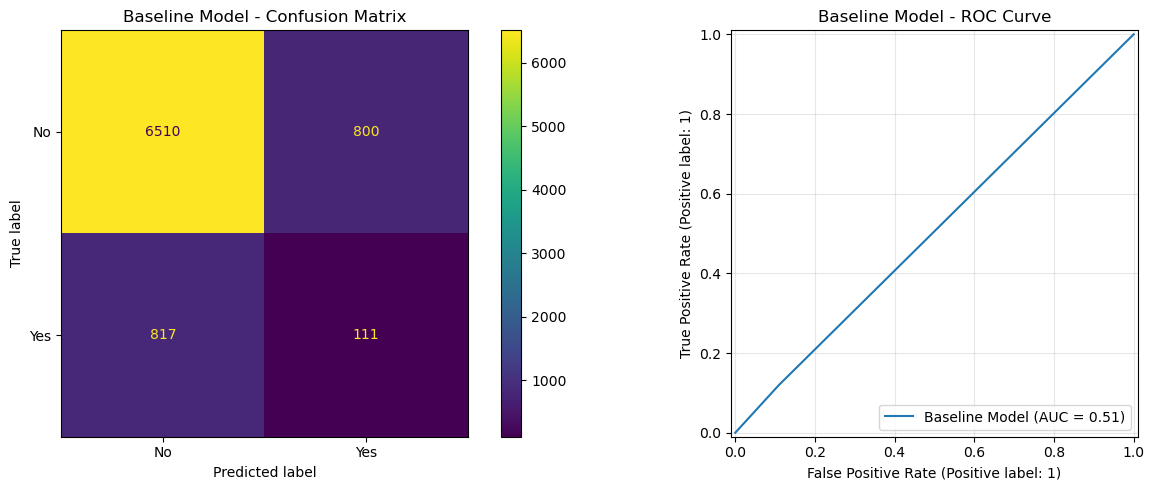

In [26]:
# Score the Baseline Model
# Display classification report, confusion matrix, and ROC curve for baseline

y_pred_baseline = baseline.predict(X_test_processed)
y_pred_proba_baseline = baseline.predict_proba(X_test_processed)[:, 1]

print("Classification Report - Baseline Model (DummyClassifier):")
print(classification_report(y_test, y_pred_baseline, target_names=['No Subscription (0)', 'Subscription (1)']))

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
disp_cm_baseline = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=['No', 'Yes'])
disp_cm_baseline.plot(ax=axes[0])
axes[0].set_title('Baseline Model - Confusion Matrix')

# ROC Curve
RocCurveDisplay.from_estimator(
    baseline, X_test_processed, y_test, ax=axes[1], name='Baseline Model'
)
axes[1].set_title('Baseline Model - ROC Curve')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Understanding the Baseline

A **baseline model** establishes the minimum performance your classifiers must beat. The `DummyClassifier` with `strategy='stratified'` is ideal because:

1. **No learning required** - Predicts based purely on class distribution in training data
2. **Easy benchmark** - If your models can't beat this, there's a fundamental problem
3. **Class imbalance aware** - Respects the real class proportions (not always 50/50)

**Why 'stratified'?** It randomly predicts while respecting class distribution. For a balanced or imbalanced dataset, this represents "random but informed" guessing.

#### About the Logistic Regression Pipeline

The **Pipeline approach** is best practice because:

1. **Prevents data leakage** - Preprocessor is fitted only on training data
2. **Reproducible** - Preprocessing and modeling are encapsulated together
3. **Easy to extend** - Add hyperparameter tuning, cross-validation, etc.
4. **Production-ready** - Single object can be saved and redeployed

**Key parameters:**
- `max_iter=1000` - Allows more iterations to converge (default is 100)
- `solver='lbfgs'` - Better for smaller datasets
- `random_state=42` - Reproducibility

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [31]:
# Logistic Regression Pipeline
# Pipeline approach allows us to encapsulate preprocessing and model together

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('logistic_regression', LogisticRegression())
])

# Train the model
start_time = time.time()
lr_pipeline.fit(X_train, y_train)
lr_train_time = time.time() - start_time

# Score the model using AUC-ROC
lr_train_proba = lr_pipeline.predict_proba(X_train)[:, 1]
lr_test_proba = lr_pipeline.predict_proba(X_test)[:, 1]

lr_train_acc = roc_auc_score(y_train, lr_train_proba)
lr_test_acc = roc_auc_score(y_test, lr_test_proba)

print("="*80)
print("LOGISTIC REGRESSION PIPELINE")
print("="*80)
print(f"Training Time: {lr_train_time:.4f} seconds")
print(f"Training AUC-ROC: {lr_train_acc:.4f}")

print(f"Test AUC-ROC: {lr_test_acc:.4f}")
print("="*80)
print(f"Improvement over baseline: {(lr_test_acc - baseline_test_acc):.4f}")

LOGISTIC REGRESSION PIPELINE
Training Time: 0.0670 seconds
Training AUC-ROC: 0.6957
Test AUC-ROC: 0.6896
Improvement over baseline: 0.1845


### Problem 9: Score the Model

What is the accuracy of your model?

Classification Report - Logistic Regression:
                     precision    recall  f1-score   support

No Subscription (0)       0.91      0.99      0.95      7310
   Subscription (1)       0.69      0.18      0.29       928

           accuracy                           0.90      8238
          macro avg       0.80      0.59      0.62      8238
       weighted avg       0.88      0.90      0.87      8238



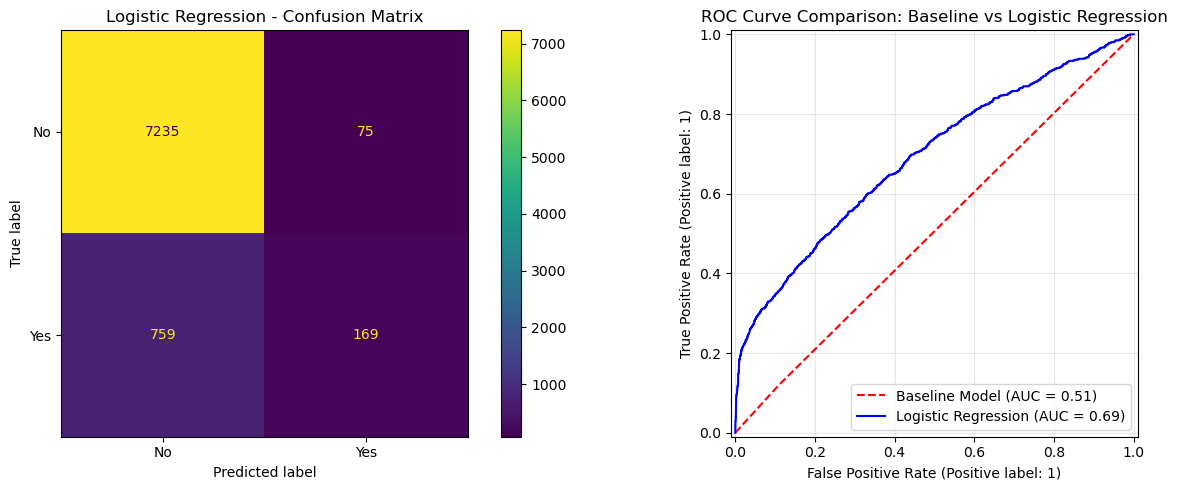

In [33]:
# Display detailed classification report, confusion matrix, and ROC curve
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, RocCurveDisplay
import matplotlib.pyplot as plt

y_pred = lr_pipeline.predict(X_test)
y_pred_proba = lr_pipeline.predict_proba(X_test)[:, 1]  # Probability of class 1

print("Classification Report - Logistic Regression:")
print(classification_report(y_test, y_pred, target_names=['No Subscription (0)', 'Subscription (1)']))

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp_cm.plot(ax=axes[0])
axes[0].set_title('Logistic Regression - Confusion Matrix')

# ROC Curve - Compare Baseline vs Logistic Regression
RocCurveDisplay.from_estimator(
    baseline, X_test_processed, y_test, ax=axes[1], name='Baseline Model', color='red', linestyle='--'
)
RocCurveDisplay.from_estimator(
    lr_pipeline, X_test, y_test, ax=axes[1], name='Logistic Regression', color='blue'
)
axes[1].set_title('ROC Curve Comparison: Baseline vs Logistic Regression')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |


Using KNN algorithm with its Default Parameters

In [35]:
# Creating a Pipeline for KNN
KNN_default= Pipeline([("preprocessor", preprocessor), ('KNN',KNeighborsClassifier())])

# Train the model
KNN_default_start= time.time()
KNN_default.fit(X_train,y_train)
KNN_default_end= time.time()
KNN_default_train_time=KNN_default_end-KNN_default_start
KNN_default_train_time

0.04609203338623047

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

##### Questions